<a href="https://colab.research.google.com/github/Alk207-lab/Projects_A/blob/main/iris%20flower.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("Libraries imported successfully.")


Libraries imported successfully.


In [8]:
from google.colab import files

file_path = "/content/IRIS1.xlsx"

if not os.path.exists(file_path):
    print("IRIS1.xlsx was not found in /content.")
    print("Please upload the Excel file.")
    uploaded = files.upload()
    file_path = "/content/" + next(iter(uploaded))

# Reverted to pd.read_excel because the uploaded file (IRIS1.xlsx) is an Excel file.
df = pd.read_excel(file_path, sheet_name="IRIS")

print("Dataset loaded successfully.")
print("Shape:", df.shape)
display(df.head())

Dataset loaded successfully.
Shape: (150, 5)


,Unnamed: 0,Unnamed: 1,petal_length,petal_width,species
0,NaN,NaN,1.4,0.2,Iris-setosa
1,NaN,NaN,1.4,0.2,Iris-setosa
2,NaN,NaN,1.3,0.2,Iris-setosa
3,NaN,NaN,1.5,0.2,Iris-setosa
4,NaN,NaN,1.4,0.2,Iris-setosa


In [9]:
# 3. Basic data preprocessing

# Remove completely empty columns (the supplied workbook contains blank columns).
df = df.dropna(axis=1, how="all").copy()

# Standardize column names.
df.columns = [str(col).strip().lower() for col in df.columns]

# Clean text in the target column.
df["species"] = df["species"].astype(str).str.strip()

# Keep only the required modeling columns.
features = ["petal_length", "petal_width"]
target = "species"

# Convert feature columns to numeric and remove invalid/missing rows.
for col in features:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=features + [target]).copy()
df = df.drop_duplicates().reset_index(drop=True)

print("After basic preprocessing:")
print("Shape:", df.shape)
print("\nMissing values:")
print(df[features + [target]].isnull().sum())
print("\nSpecies counts:")
print(df[target].value_counts())
display(df.head())


After basic preprocessing:
Shape: (103, 3)

Missing values:
petal_length    0
petal_width     0
species         0
dtype: int64

Species counts:
species
Iris-virginica     45
Iris-versicolor    36
Iris-setosa        22
Name: count, dtype: int64


,petal_length,petal_width,species
0,1.4,0.2,Iris-setosa
1,1.3,0.2,Iris-setosa
2,1.5,0.2,Iris-setosa
3,1.7,0.4,Iris-setosa
4,1.4,0.3,Iris-setosa


In [10]:
# 4. Prepare X and y

X = df[features].copy()
y_text = df[target].copy()

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_text)

print("Feature columns:", features)
print("Classes:", list(label_encoder.classes_))
print("\nEncoded class mapping:")
for number, name in enumerate(label_encoder.classes_):
    print(f"{number} -> {name}")


Feature columns: ['petal_length', 'petal_width']
Classes: ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']

Encoded class mapping:
0 -> Iris-setosa
1 -> Iris-versicolor
2 -> Iris-virginica


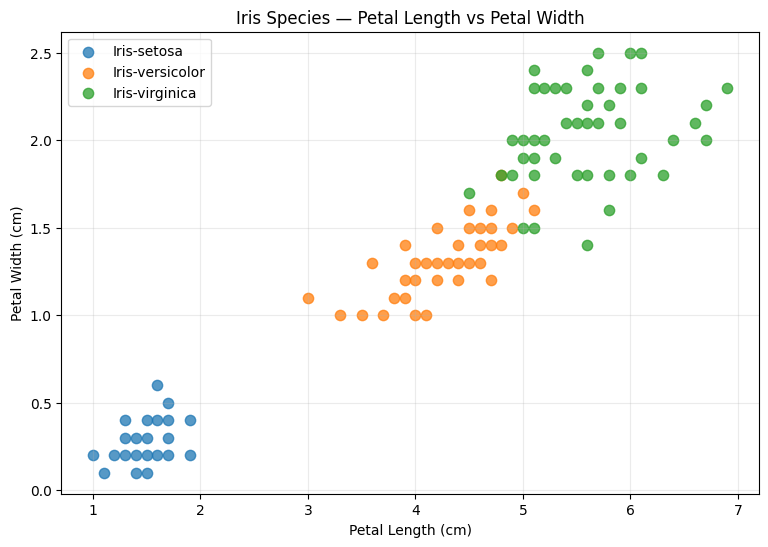

In [11]:
# 5. Visualize the data using a scatter plot

plt.figure(figsize=(9, 6))

for class_name in label_encoder.classes_:
    subset = df[df[target] == class_name]
    plt.scatter(
        subset["petal_length"],
        subset["petal_width"],
        s=55,
        alpha=0.75,
        label=class_name
    )

plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.title("Iris Species — Petal Length vs Petal Width")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


In [12]:
# 6. Split the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))


Training samples: 82
Testing samples : 21


In [13]:
# 7. Train the Logistic Regression classification model
#
# StandardScaler performs basic feature scaling before Logistic Regression.
# Logistic Regression is appropriate here because the target has 3 species classes.

model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

model.fit(X_train, y_train)

print("Model training completed successfully.")


Model training completed successfully.


In [14]:
# 8. Provide slope/coefficient and intercept values

classifier = model.named_steps["classifier"]

# With two input features, each class has two coefficients:
# coefficient for petal_length and coefficient for petal_width.
coef_df = pd.DataFrame(
    classifier.coef_,
    columns=features,
    index=label_encoder.classes_
)

intercept_df = pd.DataFrame(
    {"intercept": classifier.intercept_},
    index=label_encoder.classes_
)

print("Slope / coefficient values:")
display(coef_df)

print("Intercept values:")
display(intercept_df)

print("\nInterpretation:")
print("For each species, the model has one coefficient (slope) for petal_length")
print("and one coefficient (slope) for petal_width, plus one intercept.")
print("Because StandardScaler is used, these coefficients are for standardized features.")


Slope / coefficient values:


,petal_length,petal_width
Iris-setosa,-2.131048,-1.793234
Iris-versicolor,-0.006390,-0.352634
Iris-virginica,2.137438,2.145868


Intercept values:


,intercept
Iris-setosa,-1.855102
Iris-versicolor,1.687407
Iris-virginica,0.167695



Interpretation:
For each species, the model has one coefficient (slope) for petal_length
and one coefficient (slope) for petal_width, plus one intercept.
Because StandardScaler is used, these coefficients are for standardized features.


In [15]:
# 9. Predict the test set and calculate accuracy metrics

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision (Weighted)", "Recall (Weighted)", "F1-Score (Weighted)"],
    "Score": [accuracy, precision, recall, f1]
})

display(metrics_df)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)


,Metric,Score
0,Accuracy,0.857143
1,Precision (Weighted),0.858730
2,Recall (Weighted),0.857143
3,F1-Score (Weighted),0.855408



Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         5
Iris-versicolor       0.83      0.71      0.77         7
 Iris-virginica       0.80      0.89      0.84         9

       accuracy                           0.86        21
      macro avg       0.88      0.87      0.87        21
   weighted avg       0.86      0.86      0.86        21



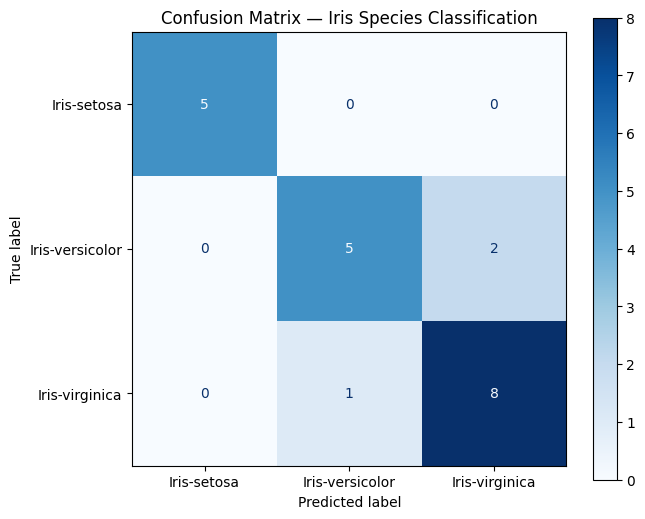

In [16]:
# 10. Confusion matrix

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, cmap="Blues", values_format="d")
plt.title("Confusion Matrix — Iris Species Classification")
plt.show()


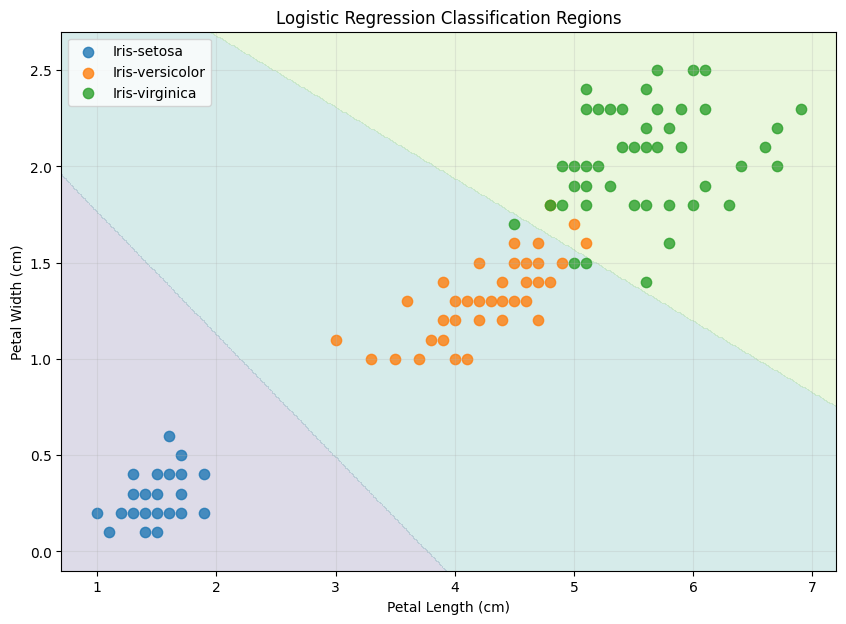

In [17]:
# 11. Visualize the classification decision regions

# Because the model uses exactly two features, we can visualize its
# classification regions in a 2D feature space.

x_min, x_max = X[features[0]].min() - 0.3, X[features[0]].max() + 0.3
y_min, y_max = X[features[1]].min() - 0.2, X[features[1]].max() + 0.2

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 400),
    np.linspace(y_min, y_max, 400)
)

grid = pd.DataFrame({
    features[0]: xx.ravel(),
    features[1]: yy.ravel()
})

Z = model.predict(grid).reshape(xx.shape)

plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z, alpha=0.18, levels=np.arange(len(label_encoder.classes_) + 1) - 0.5)

for class_id, class_name in enumerate(label_encoder.classes_):
    subset = df[y == class_id]
    plt.scatter(
        subset["petal_length"],
        subset["petal_width"],
        s=55,
        alpha=0.8,
        label=class_name
    )

plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.title("Logistic Regression Classification Regions")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


In [18]:
# 12. Predict the species of a new flower

# Change these values to test your own flower.
new_flower = pd.DataFrame({
    "petal_length": [4.5],
    "petal_width": [1.5]
})

predicted_class_id = model.predict(new_flower)[0]
predicted_species = label_encoder.inverse_transform([predicted_class_id])[0]

print("New flower:")
display(new_flower)
print("Predicted species:", predicted_species)

# Optional class probabilities
probabilities = model.predict_proba(new_flower)[0]
probability_df = pd.DataFrame({
    "Species": label_encoder.classes_,
    "Probability": probabilities
}).sort_values("Probability", ascending=False)

display(probability_df)


New flower:


,petal_length,petal_width
0,4.5,1.5


Predicted species: Iris-versicolor


,Species,Probability
1,Iris-versicolor,0.701667
2,Iris-virginica,0.285874
0,Iris-setosa,0.012459


In [19]:
# 13. Optional: save the cleaned dataset and model coefficients

cleaned_file = "/content/IRIS_cleaned.csv"
coefficients_file = "/content/IRIS_logistic_coefficients.csv"

df.to_csv(cleaned_file, index=False)

coefficients_output = coef_df.copy()
coefficients_output["intercept"] = classifier.intercept_
coefficients_output.to_csv(coefficients_file)

print("Saved:")
print(cleaned_file)
print(coefficients_file)


Saved:
/content/IRIS_cleaned.csv
/content/IRIS_logistic_coefficients.csv
